In [3]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## The dataset imported from the kagal is already normalized
we will just see if its imbalanced, and if it needs cleaning and some preprocessing

In [4]:
df = pd.read_csv("data\creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


All the V1,V2,... are the consequences of the Dimensionality reduction done by the dataset owner,
to maintain confidentiality, its done via PCA only Time and Amount has not been Transformed using PCA

### quick note: the data is of EU so the amount is in Euro

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
#checking for any null values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

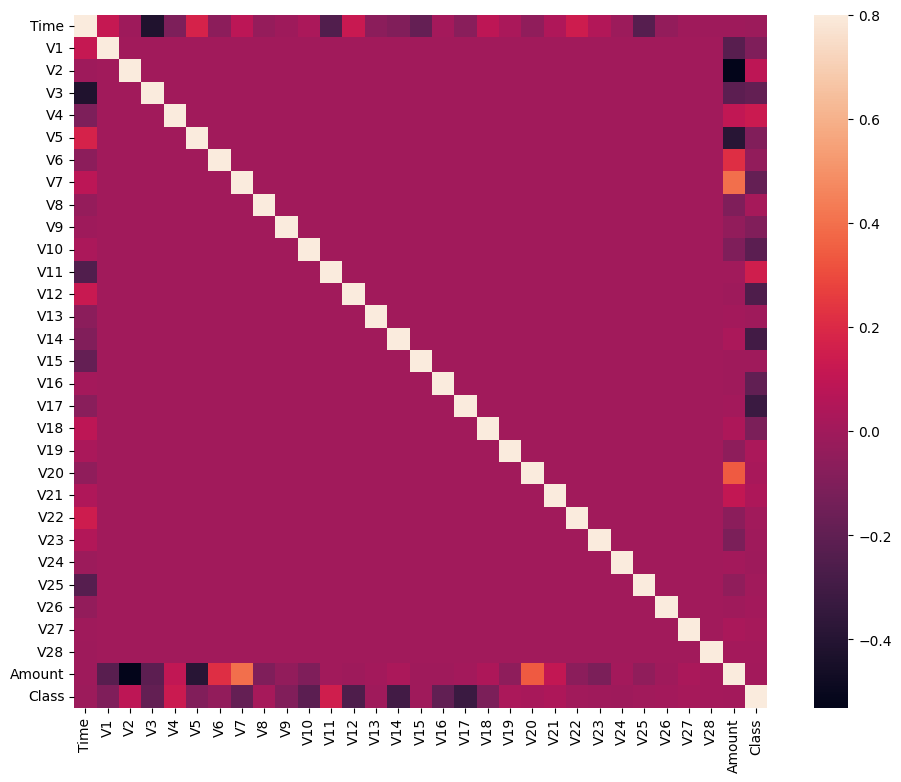

In [8]:
df.columns
plt.figure(figsize=(12,9))
sns.heatmap(df.corr(),vmax=.8,square=True)
plt.show()

All the Features are filled and no record has anu null values so we will proceed to check the
imbalance data


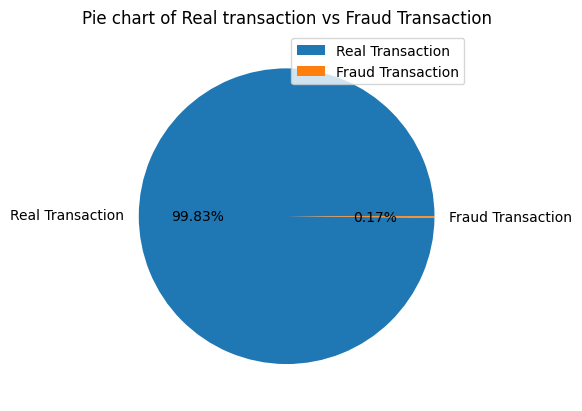

In [9]:
real_transaction_count,fraud_transaction_count = df['Class'].value_counts()
pie_data = [real_transaction_count,fraud_transaction_count]
labels = ["Real Transaction", "Fraud Transaction"]
plt.title("Pie chart of Real transaction vs Fraud Transaction")
plt.pie(pie_data,labels=labels,autopct='%1.2f%%')
plt.legend(labels)
plt.show()

<BarContainer object of 2 artists>

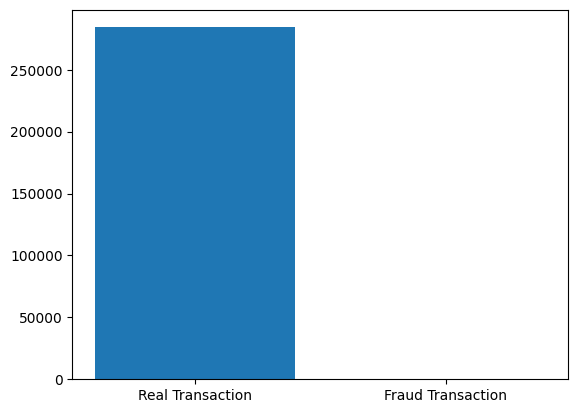

In [10]:
plt.bar(labels,pie_data)

### The barchart just seems pointless since fraud transaction arent even visible 😭

### Notes from kaggle documentation
0 -> Its a valid transaction

1 -> Its a fraud transaction  

so, we ahve 284315 successful transaction and 492 fraud so its highly skewed 


### MAJOR PROBLEM WITH THIS DATASET

This dataset is highly imbalanced, as most of the transaction are Real and not fraud,  
We saw it in the pie-chart that we only got 0.172749% of fraud data while the rest 
are Real transaction

- why this is a problem?

    if we just go ahead and fit this to our model than the model will predict the result accurately for the legitmate case but when exposed to fradulent case it might not perform well, even if the model scores high on testing, lets say 95% but if it cannot predict the fradulent case than that model is a garbage

# A wrong prediction on fradulent case is more costly than wrong prediction on legitmate case.

In [11]:
# expressing the above result in the percentage format 
print(df['Class'].value_counts(normalize=True) * 100) 


Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


Let us find the relation between the fraud transaction and amount to see if we can find any pattern

Text(0, 0.5, '1 (fraud) & 0 (Real)')

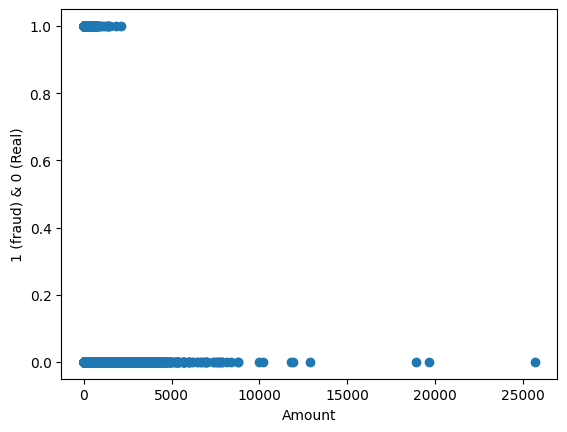

In [12]:
plt.scatter(df['Amount'],df['Class'])
plt.xlabel('Amount')
plt.ylabel('1 (fraud) & 0 (Real)')

One of the useful insight we can see is Fraud Transactions are usually under 5000 Euros.  
we will keep this in mind

### Seperate Feature and Output 
X : All the feature except the Class (output)  

y : Class feature   
also we will be using 80:20 split ratio for splitting the data 

In [13]:
from sklearn.preprocessing import StandardScaler


In [14]:
X = df.drop('Class',axis=1)
y = df['Class']
print(y)
print(X)


0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 284807, dtype: int64
            Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.18

## Z score Normalization 
we will normalize each feature so that each feature has a mean of 0 and standard  
deviation of 1  


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # z - score normalization 
print(X_scaled)


[[-1.99658302 -0.69424232 -0.04407492 ...  0.33089162 -0.06378115
   0.24496426]
 [-1.99658302  0.60849633  0.16117592 ... -0.02225568  0.04460752
  -0.34247454]
 [-1.99656197 -0.69350046 -0.81157783 ... -0.13713686 -0.18102083
   1.16068593]
 ...
 [ 1.6419735   0.98002374 -0.18243372 ...  0.01103672 -0.0804672
  -0.0818393 ]
 [ 1.6419735  -0.12275539  0.32125034 ...  0.26960398  0.31668678
  -0.31324853]
 [ 1.64205773 -0.27233093 -0.11489898 ... -0.00598394  0.04134999
   0.51435531]]


In [16]:
print(np.mean(X_scaled,axis=0))
print(np.std(X_scaled,axis=0))

[-3.06563713e-16 -1.50687242e-17 -9.58011603e-18 -8.62210442e-17
 -5.18922951e-18  3.83204641e-17  9.97928753e-18  1.23743165e-17
 -3.19337201e-18  7.23498346e-19  5.58840102e-18 -4.31105221e-17
  1.67652030e-17 -1.25240058e-17  2.59461476e-17 -2.07569181e-17
  1.83618891e-17  3.39295776e-18  2.63453191e-17  4.36593829e-18
 -1.24741094e-18 -3.64243995e-18  3.19337201e-18  8.78177302e-18
  9.58011603e-18 -5.02956091e-17  5.88777964e-18  2.44492544e-18
 -7.90858537e-18  2.91395196e-17]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


We can confirm that the normalized features mean is super close to 0 and standard deviation is  
1. 

### Split the data in 80 20 ratio

In [17]:
from sklearn.model_selection import train_test_split

X_train , X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,stratify=y)

print("Training data size: ", X_train.shape)
print("Testing data size: ", X_test.shape)

Training data size:  (227845, 30)
Testing data size:  (56962, 30)


## Balancing the data

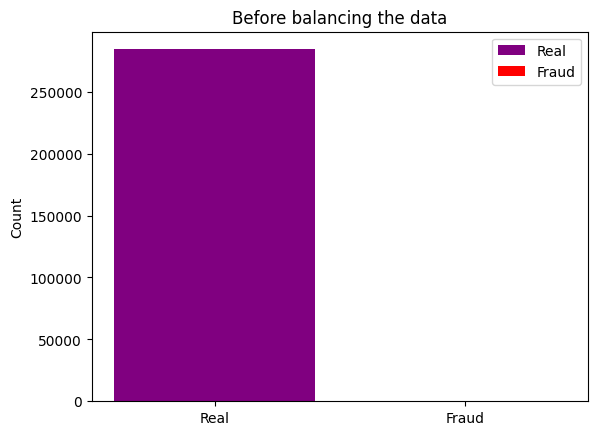

<Figure size 1000x1000 with 0 Axes>

In [18]:
from imblearn.over_sampling import SMOTE
bar_label = ["Real","Fraud"]
bar_height = [real_transaction_count,fraud_transaction_count]
plt.ylabel('Count')
plt.title("Before balancing the data")
bars = plt.bar(bar_label,bar_height,color=['purple','red'])
plt.legend(bars,bar_label)
plt.figure(figsize=(10,10))
plt.show()




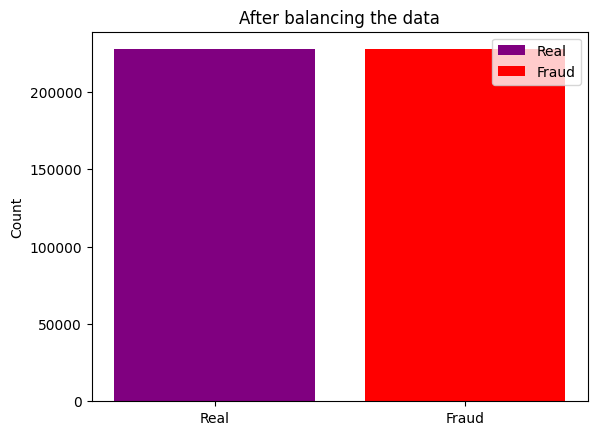

<Figure size 1000x1000 with 0 Axes>

In [19]:
smote = SMOTE(random_state=42)
X_train_balanced,y_train_balanced = smote.fit_resample(X_train,y_train)
real_count_balanced, fraud_count_balanced = y_train_balanced.value_counts()
bar_label = ["Real","Fraud"]
bar_height = [real_count_balanced,fraud_count_balanced]
plt.ylabel('Count')
plt.title("After balancing the data")
bars = plt.bar(bar_label,bar_height,color=['purple','red'])
plt.legend(bars,bar_label)
plt.figure(figsize=(10,10))
plt.show()

## How does the SMOTE balances the Data?

SMOTE -> Synthetic Minority Oversampling Technique 
It uses the minority class examples to create the new sythetic example by using the nearest neighbour approach

## Why use SMOTE , why not just copy and paste the minority over and over until its size matches the majority class?

This approach might lead to model overfitting on that specific example, lets say we 100 minority class and if we just use the same example over and over again to match the majority class than theres is a risk that model performs only well on the training data but will absolutely suck on the testing data, so thats a major drawback

- SMOTE fixes this by synthisizing new data by using nearest neighbour method so we are not using the same data to train the model

# MODEL TRAINING

In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,  
    random_state=42,
    class_weight='balanced'  
)

model.fit(X_train_balanced, y_train_balanced)
print("Model trained!")

Model trained!
